In [4]:
import h5py
import numpy as np

import requests

def get(path, params=None):
    # make HTTP GET request to path
    headers = {"api-key":"f1961aa396a1ca6daaca7b297da67975"}
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename # return the filename string

    return r

In [5]:
id = 16
z = 3.0       #z=redshift
params = {'gas':'Coordinates,ElectronAbundance,NeutralHydrogenAbundance,Density,GFM_Metallicity,InternalEnergy,StarFormationRate'}

scale_factor = 1.0 / (1+z)
little_h = 0.6774
solar_Z = 0.0127
# PS added
Msol = 1.98847*10**33
Hmass = 1.6735 * 10**-24
kpc2cm = 3.086 * 10**21

url = "http://www.tng-project.org/api/TNG50-1/snapshots/z=" + str(z) + "/subhalos/" + str(id)
sub = get(url) # get json response of subhalo properties
saved_filename = get(url + "/cutout.hdf5",params) # get and save HDF5 cutout file

with h5py.File(saved_filename) as f:
    # NOTE! If the subhalo is near the edge of the box, you must take the periodic boundary into account! (we ignore it here)
    dx = f['PartType0']['Coordinates'][:,0] - sub['pos_x']
    dy = f['PartType0']['Coordinates'][:,1] - sub['pos_y']
    dz = f['PartType0']['Coordinates'][:,2] - sub['pos_z']
    electronabnd = f['PartType0']['ElectronAbundance'][:]
    nhydrogenabnd = f['PartType0']['NeutralHydrogenAbundance'][:]
    density = f['PartType0']['Density'][:]
    gfmmetallicity = f['PartType0']['GFM_Metallicity'][:]
    intenergy = f['PartType0']['InternalEnergy'][:]
    sfr = f['PartType0']['StarFormationRate'][:]

    rr = np.sqrt(dx**2 + dy**2 + dz**2)
    rr *= scale_factor/little_h # ckpc/h -> physical kpc

    w = np.where( (rr >= 3.0) & (rr < 5.0) )    
    #print(np.mean( metals[w] ) / solar_Z)
    
    #Correct Density units
    densitycor = density*(10e10*(little_h ** 2)/(scale_factor ** 3))
    ldensity = np.log10(densitycor * (Msol/Hmass) * kpc2cm**-3) # PS edit (note use of np.log10())
    #densitycor = ((density * 10**10 * Msol*little_h**2)/(scale_factor*kpc2cm)**3)/Hmass # PS edit
    #ldensity = np.log10(densitycor) # PS comment: based 10 is np.log10(), not np.log()
    
    #Correct Star formation rate units
    lsfr = np.log10(sfr)

    #Calculate Temperature from internal energy and electron abundance (formula from https://www.tng-project.org/data/docs/faq/#gen5)
    #mmw = (4*(1.6726219e-27))/(1+3*0.76+4*0.76*electronabnd)  #mean molecular weight
    XH = 0.76
    mp = 1.6726219e-24 # units of g
    mmw = (4*mp)/(1+(3*XH)+(4*XH*electronabnd))  # mean molecular weight (units g)- PS version
    gamma = 5./3
    kB = 1.38064852 * 10**-16 # PS: cgs units (g cm2/s2/K)
    #temperature = ((5/3) - 1)*(intenergy/1.3807e-16)*(10e10)*mmw
    temperature = ((5./3) - 1)*(intenergy/kB)*(10**10)*mmw # PS: factor of 10^10 to convert from km^2 to cm^2


/var/folders/mn/cpbcr0n51d32qrxldks5z0xm0000gn/T/ipykernel_68857/336444803.py:42: RuntimeWarning: divide by zero encountered in log10
  lsfr = np.log10(sfr)


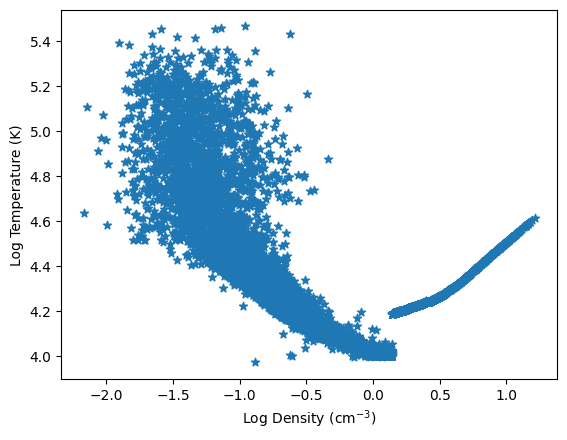

In [6]:
#Plot density vs temperature
import matplotlib.pyplot as plt

# PS - added lsfr colour-dependence
plt.scatter(ldensity, np.log10(temperature), #c=lsfr,#color= "green",
            marker= "*")
#plt.colorbar(label="Log SFR (M$_\star$/yr)")
# frequency label
plt.xlabel('Log Density (cm$^{-3}$)')
#x axis range 
# y-axis label
plt.ylabel('Log Temperature (K)')
#plt.xlim(-4,5)
#plt.ylim(4,10)     
          
# function to show the plot
plt.show()

In [ ]:
#Plot of denisty against star formation rate

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mn/cpbcr0n51d32qrxldks5z0xm0000gn/T/ipykernel_68857/3584858713.py:4: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Star formation rate (Log M$_\star$/yr)')


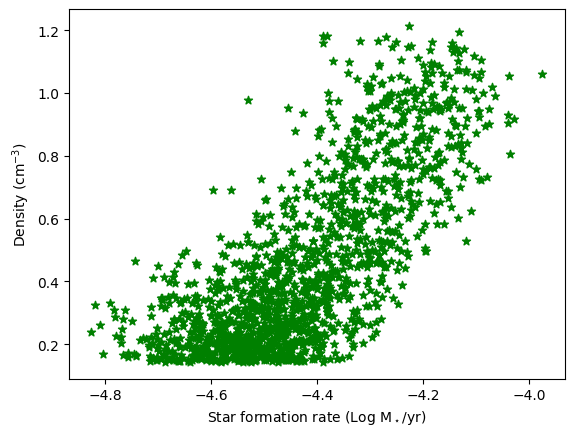

In [7]:
plt.scatter(lsfr, ldensity, color= "green",
            marker= "*")
# x-axis label
plt.xlabel('Star formation rate (Log M$_\star$/yr)')
# frequency label
plt.ylabel('Density (cm$^{-3}$)')
#x axis range 
          
          
# function to show the plot
plt.show()

In [ ]:
#Plot of density against neutral hydrogen abundance

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mn/cpbcr0n51d32qrxldks5z0xm0000gn/T/ipykernel_68857/340686158.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.colorbar(label="Log SFR (M$_\star$/yr)")


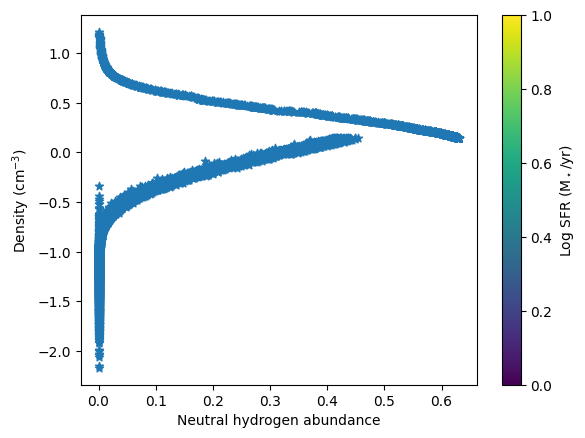

In [8]:
plt.scatter(nhydrogenabnd, ldensity, #c=lsfr,#color= "green",
            marker= "*")
plt.colorbar(label="Log SFR (M$_\star$/yr)")
# x-axis label
plt.xlabel('Neutral hydrogen abundance')
# frequency label
plt.ylabel('Density (cm$^{-3}$)')
#x axis range 
          
# function to show the plot
plt.show()

In [ ]:
#Plot of star formation rate against neutral hydrogen abundance

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mn/cpbcr0n51d32qrxldks5z0xm0000gn/T/ipykernel_68857/2112216177.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Star formation rate (Log M$_\star$/yr)')


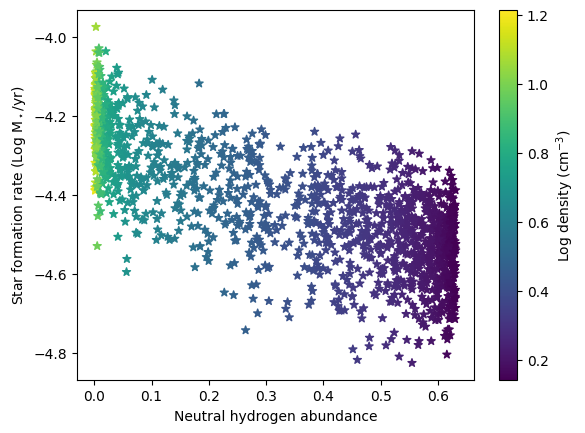

In [9]:
plt.scatter(nhydrogenabnd, lsfr, c=ldensity,#color= "green",
            marker= "*")
plt.colorbar(label="Log density (cm$^{-3}$)")
# x-axis label
plt.xlabel('Neutral hydrogen abundance')
# frequency label
plt.ylabel('Star formation rate (Log M$_\star$/yr)')
#x axis range 
          
          
# function to show the plot
plt.show()

In [10]:
#  Each halo has many more than 100 sub halos, but it’s just that the ‘get()’ function gets the 1st 100 by default. In order to read more 
#     sub halos in, you have to use an additional argument in the get() function. So, for example to read in the first 220, you have to run the code:
#  get(url, {'limit':220} )

# This is given in the illustrisTNG AIP documentation page. 

# It seems that not all subhalos have gas particles, for example. I’m not sure why this is (will have to read more into this), 
# but what it means is that we have to be careful when selected a subhalo.

# Using some code again given on the AIP documentation page, I found this way of outputting the IDs for the 1st 5 subhalos at z=3 
# with masses in the range 10**11.9 - 10**12.1.

redshift = 3.0
little_h=0.6774
mass_min = 10**10.0 / 1e10 * little_h
mass_max = 10**10.01 / 1e10 * little_h
search_query = "?mass__gt=" + str(mass_min) + "&mass__lt=" + str(mass_max)
sub_prog_url = "http://www.tng-project.org/api/TNG50-1/snapshots/z=" + str(redshift) + "/subhalos/" + search_query
sub_prog = get(sub_prog_url)
ids = [ sub_prog['results'][i]['id'] for i in range(5) ]
print(ids)

# Using this trick I’ve found that the id = 3770 should work for the particle level data. Ie. 

# url = "http://www.tng-project.org/api/TNG50-1/snapshots/z=3.0/subhalos/3770

# You might want to try doing something similar as the code I’ve written above, but for a range in galaxy stellar masses more typical for 
# GRB host galaxies. 

[16, 3787, 10849, 39761, 55213]


In [11]:
redshift

3.0